# Run BiSSGL

In [1]:
import os
import time
import gzip
import pickle
import warnings

%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np

from tqdm import TqdmSynchronisationWarning
warnings.simplefilter("ignore", TqdmSynchronisationWarning)

In [11]:
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/cdataset/noisy")
if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

In [12]:
filename_staged = os.path.join(PATH_DATA, "staged_dataset.gz")

filenames = {"input": "staged_dataset.gz", "output": "results_bissgl.gz"}

In [13]:
filename_input = os.path.join(PATH_DATA, filenames["input"])

filename_output = os.path.join(PATH_OUTPUT, filenames["output"])

In [14]:
if os.path.exists(filename_output):
    mdttm = time.strftime("%Y%m%d_%H%M%S")
    os.rename(
        filename_output,
        os.path.join(PATH_ARCHIVE, "%s%s" % (mdttm, filenames["output"])),
    )

In [15]:
from sgimc.utils import mc_split

In [16]:
from sgimc.utils import get_submatrix

In [17]:
import numpy as np


def get_metrics(real_score, predict_score):
    sorted_predict_score = np.array(
        sorted(list(set(np.array(predict_score).flatten())))
    )
    sorted_predict_score_num = len(sorted_predict_score)
    thresholds = sorted_predict_score[
        np.int32(sorted_predict_score_num * np.arange(1, 1000) / 1000)
    ]
    thresholds = np.mat(thresholds)
    thresholds_num = thresholds.shape[1]

    predict_score_matrix = np.tile(predict_score, (thresholds_num, 1))
    negative_index = np.where(predict_score_matrix < thresholds.T)
    positive_index = np.where(predict_score_matrix >= thresholds.T)
    predict_score_matrix[negative_index] = 0
    predict_score_matrix[positive_index] = 1
    TP = predict_score_matrix.dot(real_score.T)
    FP = predict_score_matrix.sum(axis=1) - TP
    FN = real_score.sum() - TP
    TN = len(real_score.T) - TP - FP - FN

    fpr = FP / (FP + TN)
    tpr = TP / (TP + FN)
    ROC_dot_matrix = np.mat(sorted(np.column_stack((fpr, tpr)).tolist())).T
    ROC_dot_matrix.T[0] = [0, 0]
    ROC_dot_matrix = np.c_[ROC_dot_matrix, [1, 1]]
    x_ROC = ROC_dot_matrix[0].T
    y_ROC = ROC_dot_matrix[1].T
    auc = 0.5 * (x_ROC[1:] - x_ROC[:-1]).T * (y_ROC[:-1] + y_ROC[1:])

    recall_list = tpr
    precision_list = TP / (TP + FP)
    PR_dot_matrix = np.mat(
        sorted(np.column_stack((recall_list, precision_list)).tolist())
    ).T
    PR_dot_matrix.T[0] = [0, 1]
    PR_dot_matrix = np.c_[PR_dot_matrix, [1, 0]]
    x_PR = PR_dot_matrix[0].T
    y_PR = PR_dot_matrix[1].T
    aupr = 0.5 * (x_PR[1:] - x_PR[:-1]).T * (y_PR[:-1] + y_PR[1:])

    f1_score_list = 2 * TP / (len(real_score.T) + TP - TN)
    accuracy_list = (TP + TN) / len(real_score.T)
    specificity_list = TN / (TN + FP)

    max_index = np.argmax(f1_score_list)
    f1_score = f1_score_list[max_index]
    accuracy = accuracy_list[max_index]
    specificity = specificity_list[max_index]
    recall = recall_list[max_index]
    precision = precision_list[max_index]
    return [aupr[0, 0], auc[0, 0], f1_score, accuracy, recall, specificity, precision]

In [18]:
random_state = np.random.RandomState(0x0BADCAFE)

In [19]:
from sgimc.utils import load, save

U, V, Y = load(filename_input)

Y = Y.astype(float)

In [20]:
dvlp_size, test_size = 0.9, 0.1

ind_dvlp, ind_test = next(
    mc_split(
        Y,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)

Y_test = get_submatrix(Y, ind_test)

## Load model

In [21]:
import sys

sys.path.append(PATH_ROOT)

from scripts.methods.BiSSGL.BiSSGLc import BiSSGL

## Implementation

In [171]:
from sklearn.model_selection import ParameterGrid

grid_dataset = ParameterGrid(
    {
        # "train_size": np.arange(0.001, 0.2, 0.02),
        "train_size": [0.81],
        "n_splits": [2],
    }
)

grid_model = ParameterGrid(
    {
        "tilde_lambda0": [10],
        "tilde_lambda1": [1],
        "lambda0": [10],
        "lambda1": [1],
        # "xi": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 50, 100],
        "xi": [1],
        "eta": [1e-7],
        "K": [50],
    }
)

# Notes:
# eta is good at 1e-8.

In [ ]:
# U = np.eye(Y.shape[0])
# V = np.eye(Y.shape[1])

In [177]:
U, V, _ = load(filename_input)
# U = U.toarray()
# V = V.toarray()

In [148]:
U = np.hstack((np.eye(Y.shape[0]), U.toarray()))
V = np.hstack((np.eye(Y.shape[1]), V.toarray()))

In [178]:
from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.model_selection import train_test_split
from scipy.special import expit


results = []
for par_dtst in tqdm(grid_dataset):
    # prepare the train dataset: take the specified share from the beginnig of the index array
    ind_train_all, _ = train_test_split(
        ind_dvlp,
        shuffle=False,
        random_state=random_state,
        test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
    )

    # Run the experiment: the model
    for par_mdl in grid_model:  # tqdm.tqdm(, desc="cv %02d" % (cv,))
        Y_train = get_submatrix(Y, ind_train_all)

        # Y_train[Y_train == 0] = 0.5
        Y_train[Y_train == -1] = 0

        # set up the model
        xi, eta, tilde_lambda0, tilde_lambda1, lambda0, lambda1, K = (
            par_mdl["xi"],
            par_mdl["eta"],
            par_mdl["tilde_lambda0"],
            par_mdl["tilde_lambda1"],
            par_mdl["lambda0"],
            par_mdl["lambda1"],
            par_mdl["K"],
        )

        model = BiSSGL(
            Y=Y_train.toarray(),
            U=U,
            V=V,
            xi=xi,
            eta=eta,
            tilde_lambda0=tilde_lambda0,
            tilde_lambda1=tilde_lambda1,
            tilde_alpha=1 / K / 5000,
            tilde_beta=1,
            lambda0=lambda0,
            lambda1=lambda1,
            alpha=1 / K / 1000,
            beta=1,
            K=K,
            max_iter=5000,
            tol=1e-10,
        )

        # fit on the whole development dataset
        est_mu, est_A, est_B, logLik = model.optimization()

        # get the score
        prob_full = expit(U @ est_A @ est_B.T @ V.T)
        prob_test = get_submatrix(prob_full, ind_test)
        scores_test = get_metrics((Y_test.data + 1) / 2, prob_test.data)
        d1_test = sum(abs(est_A).max(axis=1) > 0)
        d2_test = sum(abs(est_B).max(axis=1) > 0)

        # record the results
        results.append(
            {
                "train_size": par_dtst["train_size"],
                "xi": par_mdl["xi"],
                "eta": par_mdl["eta"],
                "tilde_lambda0": par_mdl["tilde_lambda0"],
                "tilde_lambda1": par_mdl["tilde_lambda1"],
                "lambda0": par_mdl["lambda0"],
                "lambda1": par_mdl["lambda1"],
                "K": par_mdl["K"],
                "test_score": scores_test,
                "test_d1": d1_test,
                "test_d2": d2_test,
            }
        )

  0%|          | 0/1 [00:00<?, ?it/s]

Finished with iterations of 4999


100%|██████████| 1/1 [11:28<00:00, 688.25s/it]


In [112]:
results

[{'train_size': 0.81,
  'xi': 1,
  'eta': 1e-08,
  'tilde_lambda0': 100,
  'tilde_lambda1': 1,
  'lambda0': 100,
  'lambda1': 1,
  'K': 200,
  'test_score': [0.1278269009982685,
   0.6649187438587254,
   0.03915104059344735,
   0.8267380076542935,
   0.3877551020408163,
   0.8307709614519274,
   0.020616319444444444],
  'test_d1': 1888,
  'test_d2': 797},
 {'train_size': 0.81,
  'xi': 2,
  'eta': 1e-08,
  'tilde_lambda0': 100,
  'tilde_lambda1': 1,
  'lambda0': 100,
  'lambda1': 1,
  'K': 200,
  'test_score': [0.1669986731941489,
   0.7518169754777566,
   0.05477899508877975,
   0.8140675509976592,
   0.5918367346938775,
   0.816109194540273,
   0.028718558130322838],
  'test_d1': 1888,
  'test_d2': 797},
 {'train_size': 0.81,
  'xi': 3,
  'eta': 1e-08,
  'tilde_lambda0': 100,
  'tilde_lambda1': 1,
  'lambda0': 100,
  'lambda1': 1,
  'K': 200,
  'test_score': [0.19256830518632626,
   0.7996739193652562,
   0.2054794520547945,
   0.9913796306617619,
   0.12244897959183673,
   0.99936253

In [164]:
results

[{'train_size': 0.81,
  'xi': 1,
  'eta': 1e-06,
  'tilde_lambda0': 100,
  'tilde_lambda1': 1,
  'lambda0': 100,
  'lambda1': 1,
  'K': 200,
  'test_score': [0.09887464677141548,
   0.7461115974813504,
   0.141643059490085,
   0.9887415003901461,
   0.10204081632653061,
   0.9968876556172191,
   0.23148148148148148],
  'test_d1': 1013,
  'test_d2': 993},
 {'train_size': 0.81,
  'xi': 100,
  'eta': 1e-06,
  'tilde_lambda0': 100,
  'tilde_lambda1': 1,
  'lambda0': 100,
  'lambda1': 1,
  'K': 200,
  'test_score': [0.5045517036376472,
   0.5,
   0.01804256572648943,
   0.009103407275294467,
   1.0,
   0.0,
   0.009103407275294467],
  'test_d1': 0,
  'test_d2': 0},
 {'train_size': 0.81,
  'xi': 1,
  'eta': 1e-07,
  'tilde_lambda0': 100,
  'tilde_lambda1': 1,
  'lambda0': 100,
  'lambda1': 1,
  'K': 200,
  'test_score': [0.0288811228754503,
   0.711732245020402,
   0.08222811671087533,
   0.9742875190428417,
   0.12653061224489795,
   0.9820758962051898,
   0.060903732809430254],
  'test_d1'

In [169]:
results

[{'train_size': 0.81,
  'xi': 1,
  'eta': 1e-07,
  'tilde_lambda0': 10,
  'tilde_lambda1': 1,
  'lambda0': 10,
  'lambda1': 1,
  'K': 50,
  'test_score': [0.3681811792495551,
   0.9009260506362436,
   0.39611650485436894,
   0.9884442462750344,
   0.4163265306122449,
   0.9937003149842508,
   0.37777777777777777],
  'test_d1': 2546,
  'test_d2': 1206},
 {'train_size': 0.81,
  'xi': 100,
  'eta': 1e-07,
  'tilde_lambda0': 10,
  'tilde_lambda1': 1,
  'lambda0': 10,
  'lambda1': 1,
  'K': 50,
  'test_score': [0.35274567473219465,
   0.8893412727322818,
   0.3947939262472885,
   0.989633262735481,
   0.37142857142857144,
   0.9953127343632818,
   0.4212962962962963],
  'test_d1': 2546,
  'test_d2': 1206},
 {'train_size': 0.81,
  'xi': 1,
  'eta': 1e-08,
  'tilde_lambda0': 10,
  'tilde_lambda1': 1,
  'lambda0': 10,
  'lambda1': 1,
  'K': 50,
  'test_score': [0.4319930658055775,
   0.9149850160553198,
   0.4792626728110599,
   0.9916025712480957,
   0.42448979591836733,
   0.9968126593670317

In [179]:
results

[{'train_size': 0.81,
  'xi': 1,
  'eta': 1e-07,
  'tilde_lambda0': 10,
  'tilde_lambda1': 1,
  'lambda0': 10,
  'lambda1': 1,
  'K': 50,
  'test_score': [0.19621575282138579,
   0.8132933914528763,
   0.07354531689379191,
   0.8408575781220972,
   0.6938775510204082,
   0.8422078896055197,
   0.03883051621745089],
  'test_d1': 1888,
  'test_d2': 797}]

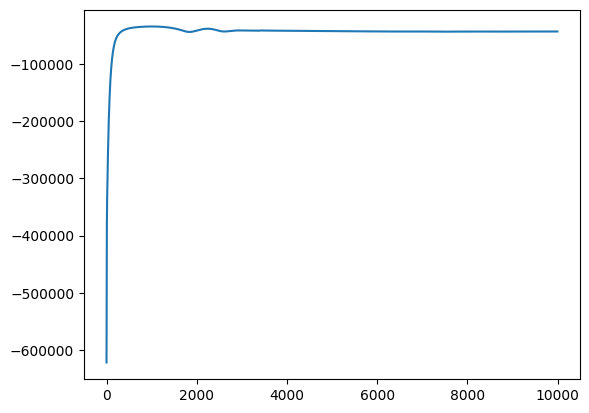

In [107]:
plt.plot(logLik)
# plt.stem(np.sort(abs(est_A).max(axis=1)))

In [ ]:
with gzip.open(os.path.join(PATH_OUTPUT, "results_bissgl_xi.gz"), "wb+", 4) as fout:
    pickle.dump(results, fout)

---